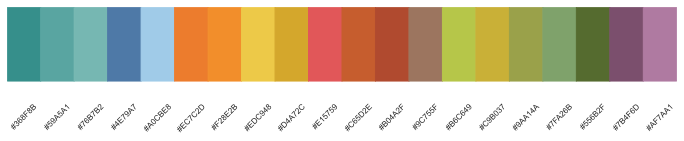

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import re

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# Configure Matplotlib fonts
plt.rcParams.update({
    "text.usetex": False,                # no LaTeX
    "font.family": "sans-serif",         # base font family
    "font.sans-serif": ["Helvetica"],    # prefer Helvetica
    "mathtext.fontset": "custom",        # custom math font
    "mathtext.rm": "Helvetica",          # math regular
    "mathtext.it": "Helvetica:italic",   # math italic
    "mathtext.bf": "Helvetica:bold",     # math bold
    "font.size": 15                       # global font size
})

matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 
matplotlib.rc('text', usetex='false') 


# define custom colormaps
norm = matplotlib.colors.Normalize(-1,1)

# Warm 70s color scheme
palette_20_warm70s_final = [
    '#368F8B', '#59A5A1', '#76B7B2', '#4E79A7', '#A0CBE8',
    '#EC7C2D', '#F28E2B', '#EDC948', '#D4A72C',
    '#E15759', '#C65D2E', '#B04A2F', '#9C755F',
    '#B6C649', '#C9B037', '#9AA14A', '#7FA26B', '#556B2F',
    '#7B4F6D', '#AF7AA1'
]



colors_warm70s = [[norm(-1.0), palette_20_warm70s_final[0]],
          [norm( 0.6), palette_20_warm70s_final[5]]]
cmap_warm70s = matplotlib.colors.LinearSegmentedColormap.from_list("", colors_warm70s)
colorlist_warm70s = ['#368F8B', '#EC7C2D', '#B6C649','#AF7AA1','#EDC948', '#D4A72C','#A0CBE8', '#7FA26B']

sns.set_palette(colorlist_warm70s)
sns.set_style('white')

# Visualize palette
fig, ax = plt.subplots(figsize=(12, 2))
for i, color in enumerate(palette_20_warm70s_final):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.3, color, ha='center', va='top', fontsize=8, rotation=45)

ax.set_xlim(0, len(palette_20_warm70s_final))
ax.set_ylim(-0.5, 1)
ax.axis('off')
plt.show()



In [28]:
df = pd.read_csv("data.csv")

dates = df.loc[0,df.columns.str.contains('Date')].values

scores = [
    "Lire et comprendre une consigne",
    "Comprendre un texte lu seul (13 lignes)",
    "Ortographier correctement sous la dictee",
    "Copie un texte sans erreur de 4 phrases",
    "Rediger un texte de 4 phrases"
]

names = {
       "Lire et comprendre une consigne": "Lire et comprendre \nune consigne",
       "Comprendre un texte lu seul (13 lignes)": "Comprendre un texte \nlu seul (13 lignes)",
       "Ortographier correctement sous la dictee": "Ortographier correctement \nsous la dictee",
       "Copie un texte sans erreur de 4 phrases": "Copie un texte sans erreur \nde 4 phrases",
       "Rediger un texte de 4 phrases": "Rediger un texte \nde 4 phrases"
}

In [29]:
dates

<StringArray>
['Janvier', 'Mars', 'Juin']
Length: 3, dtype: str

In [30]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.default'] = 'regular'
def radar_generic(row, scores, names):

    # Detect available suffixes in dataframe
    suffixes = sorted(
        set(int(m.group(1)) for c in row.index
            for m in [re.search(r'_(\d+)$', c)] if m)
    )
    last_suffix = max(suffixes)

    # Build metric list that actually exists in data
    base_metrics = []
    for s in scores:
        for suf in suffixes:
            if f"{s}_{suf}" in row.index:
                base_metrics.append(s)
                break   # metric exists → keep it
    # Remove duplicates
    base_metrics = list(dict.fromkeys(base_metrics))

    # Collect values
    values_per_measurement = {}
    for suf in suffixes:
        values_per_measurement[suf] = [row[f"{m}_{suf}"] for m in base_metrics]

    seuil = [row[f"{m}_seuil"] for m in base_metrics]

    # Close radar loop
    def close(v): return v + v[:1]
    angles = np.linspace(0, 2*np.pi, len(base_metrics)+1)

    for suf in suffixes:
        values_per_measurement[suf] = close(values_per_measurement[suf])
    seuil = close(seuil)

    # Plot
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

    for suf, iter in zip(suffixes, range(len(suffixes))):
        lw = 3 if suf == last_suffix else 1.5
        alpha = 0.25 if suf == last_suffix else 0.1
        ax.plot(angles, values_per_measurement[suf], 
                color=colorlist_warm70s[iter], lw=lw)
        ax.fill(angles, values_per_measurement[suf], 
                color=colorlist_warm70s[iter], alpha=alpha)

    # Threshold
    # ax.plot(angles, seuil, linestyle="--", color=colors["seuil"], lw=2)

    # Axis labels
    # Remove default labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Flip specific labels (top-left and bottom-right)
    # Identify indices by position in base_metrics
    # i_top_left = 1          # usually second label (adjust if needed)
    # i_bottom_right = 3       # usually fourth label (adjust if needed)

    # base_metrics[i_top_left], base_metrics[i_bottom_right] = \
    #     base_metrics[i_bottom_right], base_metrics[i_top_left]


    # Custom curved-style labels WITH red threshold coloring
    rmax = ax.get_rmax()

    for angle, metric in zip(angles[:-1], base_metrics):

        final_val = row[f"{metric}_{last_suffix}"]
        seuil_val = row[f"{metric}_seuil"]
        color = "red" if final_val < seuil_val else "black"

        angle_deg = np.degrees(angle)
        rotation = angle_deg - 90
        if 90 < angle_deg < 270:
            rotation += 180

        ax.text(angle, rmax * 1.12, names[metric],
                color=color,
                fontweight="bold" if color=="red" else "normal",
                rotation=rotation,
                rotation_mode='anchor',
                ha='center', va='center')

    # ax.set_title(row["Prenom"], fontsize=15)
    ax.legend(bbox_to_anchor=(1.25,1.1)).set_visible(False)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_29897/3015853727.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.25,1.1)).set_visible(False)


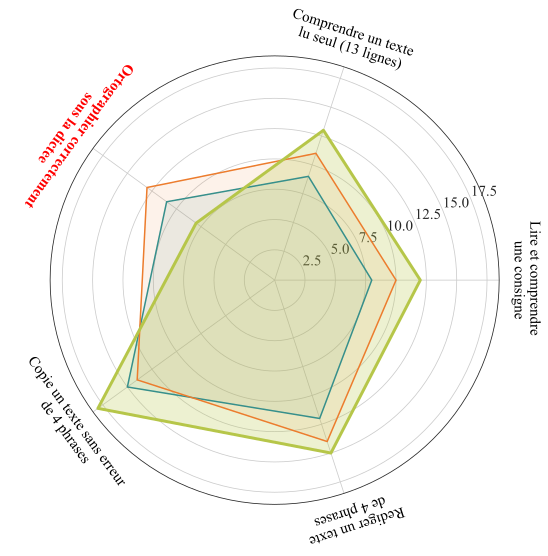

/tmp/ipykernel_29897/3015853727.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.25,1.1)).set_visible(False)


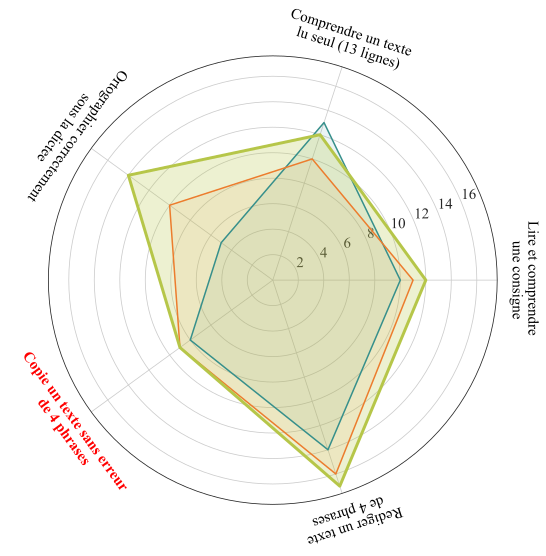

In [32]:
for _, row in df.iterrows():
    radar_generic(row, scores, names)


In [34]:
import matplotlib
matplotlib.use("Agg")

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import io
import zipfile
from io import BytesIO

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],   # Helvetica not on Linux
    "font.size": 14
})

# COLORS
norm = matplotlib.colors.Normalize(-1,1)

palette_20_warm70s_final = [
    '#368F8B', '#59A5A1', '#76B7B2', '#4E79A7', '#A0CBE8',
    '#EC7C2D', '#F28E2B', '#EDC948', '#D4A72C',
    '#E15759', '#C65D2E', '#B04A2F', '#9C755F',
    '#B6C649', '#C9B037', '#9AA14A', '#7FA26B', '#556B2F',
    '#7B4F6D', '#AF7AA1'
]

colorlist_warm70s = ['#368F8B', '#EC7C2D', '#B6C649','#AF7AA1','#EDC948', '#D4A72C','#A0CBE8', '#7FA26B']
sns.set_palette(colorlist_warm70s)
sns.set_style('white')

def detect_suffixes(df):
    return sorted(set(
        int(m.group(1))
        for c in df.columns
        for m in [re.search(r'_(\d+)$', c)]
        if m
    ))

def detect_metrics(df):
    metrics = sorted(set(
        re.sub(r'_\d+$', '', c)
        for c in df.columns if re.search(r'_\d+$', c)
    ))
    # Keep only metrics with thresholds
    return [m for m in metrics if f"{m}_seuil" in df.columns]

# RADAR FUNCTION
def radar_generic(row, df):
    suffixes = detect_suffixes(df)
    metrics  = detect_metrics(df)
    last_suffix = max(suffixes)

    # Collect values (handle missing metrics gracefully)
    values_per_measurement = {}
    for suf in suffixes:
        vals = []
        for m in metrics:
            col = f"{m}_{suf}"
            vals.append(row[col] if col in row and pd.notna(row[col]) else np.nan)
        values_per_measurement[suf] = vals

    # Thresholds
    seuil = [row[f"{m}_seuil"] for m in metrics]

    # Close radar loop
    def close(v): return v + v[:1]
    angles = np.linspace(0, 2*np.pi, len(metrics)+1)

    for suf in suffixes:
        values_per_measurement[suf] = close(values_per_measurement[suf])
    seuil = close(seuil)

    # Plot
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

    for i, suf in enumerate(suffixes):
        lw = 3 if suf == last_suffix else 1.5
        alpha = 0.3 if suf == last_suffix else 0.1
        color = colorlist_warm70s[i % len(colorlist_warm70s)]

        ax.plot(angles, values_per_measurement[suf], color=color, lw=lw)
        ax.fill(angles, values_per_measurement[suf], color=color, alpha=alpha)

    # Threshold line
    # ax.plot(angles, seuil, linestyle="--", color="black", lw=2)

    # Remove default xticks
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Labels with red threshold logic
    rmax = ax.get_rmax()

    for angle, metric in zip(angles[:-1], metrics):
        final_val = row.get(f"{metric}_{last_suffix}", np.nan)
        seuil_val = row.get(f"{metric}_seuil", np.nan)
        color = "red" if pd.notna(final_val) and pd.notna(seuil_val) and final_val < seuil_val else "black"

        angle_deg = np.degrees(angle)
        rotation = angle_deg - 90
        if 180 < angle_deg < 327:
            rotation += 180

        ax.text(angle, rmax * 1.15, metric,
                color=color,
                fontweight="bold" if color=="red" else "normal",
                rotation=rotation,
                rotation_mode='anchor',
                ha='center', va='center')

    # Legend (dates)
    dates = df.loc[0, df.columns.str.contains("Date")].values
    ax.legend(dates, bbox_to_anchor=(1.25,1.1))

    plt.tight_layout()
    plt.savefig(f"{row['Prenom']}.png")
    plt.close()


# STREAMLIT UI
st.title("📊 Radar d’évaluation des élèves")
st.write("Téléversez votre fichier CSV de notes.")

uploaded_file = st.file_uploader("📂 Importer CSV", type=["csv"])

scores = [
    "Lire et comprendre une consigne",
    "Comprendre un texte lu seul (13 lignes)",
    "Ortographier correctement sous la dictee",
    "Copie un texte sans erreur de 4 phrases",
    "Rediger un texte de 4 phrases"
]

names = {
    "Lire et comprendre une consigne": "Lire et comprendre\nune consigne",
    "Comprendre un texte lu seul (13 lignes)": "Comprendre un texte\nlu seul (13 lignes)",
    "Ortographier correctement sous la dictee": "Orthographier\nsous la dictée",
    "Copie un texte sans erreur de 4 phrases": "Copie sans erreur\nde 4 phrases",
    "Rediger un texte de 4 phrases": "Rédiger un texte\nde 4 phrases"
}

# if uploaded_file:
df = pd.read_csv('data2.csv')
# st.success("File uploaded!")

for _, row in df.iterrows():
    radar_generic(row, df)
    #     st.image(f"{row['Prenom']}.png")
    # # df = pd.read_csv(uploaded_file)

    # # st.success("✅ Fichier chargé")

    # # dates = df.loc[0, df.columns.str.contains("Date")].values
    # # students = df["Prenom"].tolist()

    # # student = st.selectbox("👩‍🎓 Choisir un élève", students)

    # # row = df[df["Prenom"] == student].iloc[0]
    # # fig = radar_generic(row, scores, names, dates)
    # # st.pyplot(fig)



    # zip_buffer = BytesIO()
    # with zipfile.ZipFile(zip_buffer, "w") as zf:
    #     for _, row in df.iterrows():
    #         radar_generic(row, df)
    #         fname = f"{row['Prenom']}.png"
    #         zf.write(fname)

    # st.download_button(
    #     "Download all plots (ZIP)",
    #     data=zip_buffer.getvalue(),
    #     file_name="student_radar_plots.zip",
    #     mime="application/zip"
    # )



2026-02-14 16:11:28.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.773 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.773 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.773 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 16:11:28.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

ValueError: max() arg is an empty sequence

In [35]:
df

,Prenom;A_1;B_1;Date_1;C_2;A_2;B_2;Date_2;M_3;C_3;Date_3;A_seuil;B_seuil;C_seuil;M_seuil
0,Alice;5;6;Janvier;3;7;11;Mars;12;10;Juin;6;10;...
